In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:

df = pd.read_csv("sbombry1_project_summary.csv", sep=",")
df.columns = ['project','commit','author','time','message']
df['Month'] = pd.to_datetime(df['time'], unit='s').dt.strftime('%Y-%m')
df.head()

,project,commit,author,time,message,Month
0,gabinsane_multimodal-vae-comparison,034f34e1158ffb69f5ad4ceefeff4991e312abc8,Gabriela Šejnová <g.sejnova@gmail.com>,1661779711,test_torchmmvae.py passe\n,2022-08
1,gabinsane_multimodal-vae-comparison,03541d8d436a25eb9f0da8582930647a58168a6c,Gabriela Šejnová <g.sejnova@gmail.com>,1664540067,mnist_svhn vis and labelled tsne\n,2022-09
2,gabinsane_multimodal-vae-comparison,03a1e7075edfe00bea813019c58c9861bdc305ab,Gabriela Šejnová <g.sejnova@gmail.com>,1633959855,initial\n,2021-10
3,gabinsane_multimodal-vae-comparison,03d8331004cbdae249a2fea07837ca8e1dab88e4,Gabriela Šejnová <sejnogab@ciirc.cvut.cz>,1626274150,ROS2 package structure\n,2021-07
4,gabinsane_multimodal-vae-comparison,04977864f89f12e320905b26a3732515ac675982,Gabriela Šejnová <g.sejnova@gmail.com>,1686821990,Merge remote-tracking branch 'origin/toolkit-d...,2023-06


In [46]:
prj='geoknow_linkedgeodata'
df1 = df[df['project']==prj]
df2 = df1.groupby('Month').size().reset_index(name='Commits')
monthly_counts = df2
monthly_counts['time'] = pd.to_datetime(monthly_counts['Month'])
full_date_range = pd.DataFrame({'time': pd.date_range(start=monthly_counts['time'].min(), end=monthly_counts['time'].max(), freq='MS')})
monthly_counts = pd.merge(full_date_range, monthly_counts, on='time', how='left').fillna(0)
monthly_counts['Month'] = monthly_counts['time'].dt.strftime('%Y-%m')
commits_timeseries = monthly_counts[['Month', 'Commits']].copy()
commits_timeseries = commits_timeseries.rename(columns={'Commits': '#Commits'})
commits_timeseries.to_csv(
    f'sbombry1_commits_timeseries_{prj}.csv',
    sep=',',
    index=False
)
commits_timeseries.head()

,Month,#Commits
0,2013-01,4.0
1,2013-02,0.0
2,2013-03,17.0
3,2013-04,20.0
4,2013-05,5.0


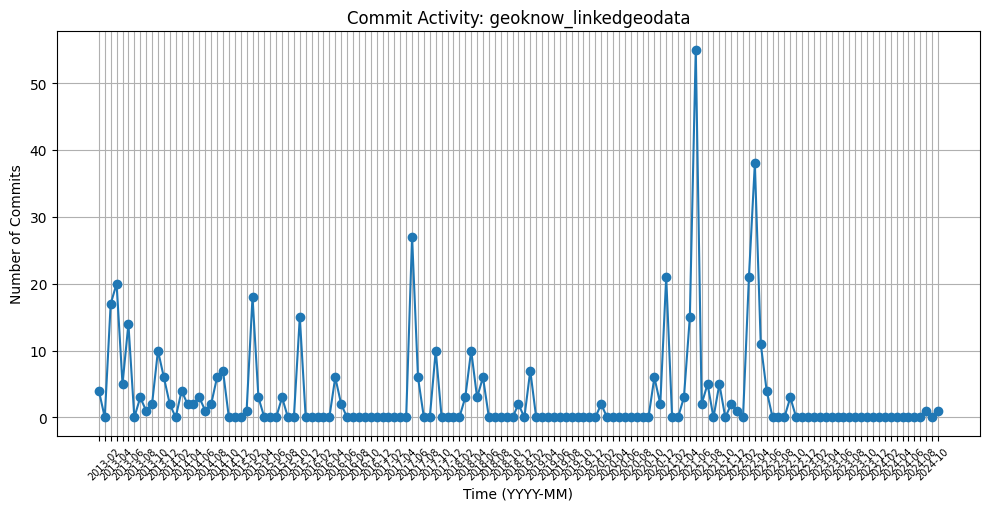

In [47]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5))
plt.plot(monthly_counts["Month"], monthly_counts["Commits"], marker="o", linestyle="-")
plt.xlabel("Time (YYYY-MM)")
plt.ylabel("Number of Commits")
plt.title("Commit Activity: "+prj)
plt.grid(True)
plt.tight_layout()
ax =  plt.gca()
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.xticks(rotation=45, fontsize=7)
plt.savefig("sbombry1_timeseries_"+prj+".png", dpi=600)
plt.show()
plt.close()

In [1]:
import requests
import pandas as pd
import time
import os


project_urls = [
    'gabinsane/multimodal-vae-comparison',
    'MansMeg/posteriordb',
    'markmfredrickson/optmatch',
    'statistikat/VIM',
    'FairRootGroup/FairRoot',
    'arfc/pride',
    'nexpy/nexpy',
    'tompollard/tableone',
    'geospace-code/pymap3d',
    'GeoKnow/LinkedGeoData'
]

API_URL = "https://api.github.com"
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")

headers = {"Accept": "application/vnd.github+json", "X-GitHub-Api-Version": "2022-11-28"}

if GITHUB_TOKEN: headers["Authorization"] = f"Bearer {GITHUB_TOKEN}"

def github_get(url, params=None):
    response = requests.get(
        url,
        headers=headers,
        params=params,
        timeout=30
    )

    if response.status_code != 200:
        raise RuntimeError(
            f"GitHub API error {response.status_code}: "
            f"{response.text}"
        )

    return response.json()

def get_repo_info(project):
    url = f"{API_URL}/repos/{project}"
    return github_get(url)

def get_all_commits(project):

    url = f"{API_URL}/repos/{project}/commits"

    commits = []
    page = 1

    while True:

        params = {
            "per_page": 100,
            "page": page
        }

        batch = github_get(url, params=params)

        if not batch:
            break

        commits.extend(batch)

        if len(batch) < 100:
            break

        page += 1

        time.sleep(0.1)

    return commits


def calculate_project_statistics(project):

    print(f"Processing {project}...")

    repo = get_repo_info(project)

    stars = repo.get("stargazers_count", 0)
    forks = repo.get("forks_count", 0)

    commits = get_all_commits(project)

    if not commits:
        return {
            "project": project,
            "number of commits": 0,
            "number of authors": 0,
            "max time": None,
            "min time": None,
            "number of stars": stars,
            "number of forks": forks,
            "last commit date": None,
            "LongestGapStart": None,
            "LongestGapEnd": None,
            "LongestGapLength": None,
            "NumCommitsAfterLastGap": 0,
            "NumberOfGapsInTimeline": 0
        }

    commit_dates = []
    authors = set()

    for commit in commits:

        commit_data = commit.get("commit", {})

        author_data = commit_data.get("author")

        if author_data:

            github_author = commit.get("author")

            if github_author and github_author.get("login"):

                authors.add(github_author["login"])

            else:

                authors.add(
                    (
                        author_data.get("name"),
                        author_data.get("email")
                    )
                )

        if author_data:

            date_string = author_data.get("date")

            if date_string:
                commit_dates.append(
                    pd.to_datetime(
                        date_string,
                        utc=True
                    )
                )

    commit_dates = sorted(commit_dates)

    number_of_commits = len(commit_dates)
    number_of_authors = len(authors)

    min_time = commit_dates[0]
    max_time = commit_dates[-1]

    gaps = []

    for i in range(1, len(commit_dates)):

        start = commit_dates[i - 1]
        end = commit_dates[i]

        gap = end - start

        gaps.append({
            "start": start,
            "end": end,
            "length": gap
        })

    if gaps:

        longest_gap = max(
            gaps,
            key=lambda x: x["length"]
        )

        longest_gap_start = longest_gap["start"]
        longest_gap_end = longest_gap["end"]
        longest_gap_length = longest_gap["length"]

        num_commits_after_gap = sum(
            date > longest_gap_end
            for date in commit_dates
        )

    else:

        longest_gap_start = None
        longest_gap_end = None
        longest_gap_length = None
        num_commits_after_gap = 0

    GAP_THRESHOLD_DAYS = 30

    number_of_gaps = sum(
        gap["length"].total_seconds()
        >= GAP_THRESHOLD_DAYS * 24 * 60 * 60
        for gap in gaps
    )

    return {
        "project": project,
        "number of commits": number_of_commits,
        "number of authors": number_of_authors,
        "max time": max_time.isoformat(),
        "min time": min_time.isoformat(),
        "number of stars": stars,
        "number of forks": forks,
        "last commit date": max_time.date().isoformat(),

        "LongestGapStart": (
            longest_gap_start.isoformat()
            if longest_gap_start
            else None
        ),

        "LongestGapEnd": (
            longest_gap_end.isoformat()
            if longest_gap_end
            else None
        ),

        # Longest gap expressed in days
        "LongestGapLength": (
            longest_gap_length.total_seconds()
            / (24 * 60 * 60)
            if longest_gap_length
            else None
        ),

        "NumCommitsAfterLastGap": num_commits_after_gap,

        "NumberOfGapsInTimeline": number_of_gaps
    }


results = []

for project in project_urls:

    try:

        result = calculate_project_statistics(project)

        results.append(result)

    except Exception as e:

        print(f"ERROR processing {project}: {e}")

        results.append({
            "project": project,
            "number of commits": None,
            "number of authors": None,
            "max time": None,
            "min time": None,
            "number of stars": None,
            "number of forks": None,
            "last commit date": None,
            "LongestGapStart": None,
            "LongestGapEnd": None,
            "LongestGapLength": None,
            "NumCommitsAfterLastGap": None,
            "NumberOfGapsInTimeline": None
        })

columns = [
    "project",
    "number of commits",
    "number of authors",
    "max time",
    "min time",
    "number of stars",
    "number of forks",
    "last commit date",
    "LongestGapStart",
    "LongestGapEnd",
    "LongestGapLength",
    "NumCommitsAfterLastGap",
    "NumberOfGapsInTimeline"
]

df = pd.DataFrame(
    results,
    columns=columns
)

df.head()



Processing gabinsane/multimodal-vae-comparison...
Processing MansMeg/posteriordb...
Processing markmfredrickson/optmatch...
Processing statistikat/VIM...
Processing FairRootGroup/FairRoot...
Processing arfc/pride...
Processing nexpy/nexpy...
Processing tompollard/tableone...
Processing geospace-code/pymap3d...
Processing GeoKnow/LinkedGeoData...


,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,gabinsane/multimodal-vae-comparison,430,6,2025-05-19T21:34:47+00:00,2021-06-29T09:38:12+00:00,34,11,2025-05-19,2024-03-25T14:21:54+00:00,2025-05-19T21:02:29+00:00,420.278183,3,11
1,MansMeg/posteriordb,1300,28,2026-09-25T08:33:06+00:00,2019-04-09T06:35:25+00:00,234,52,2026-09-25,2021-09-20T13:05:30+00:00,2022-08-09T12:36:37+00:00,322.979942,199,18
2,markmfredrickson/optmatch,1738,11,2026-09-24T14:37:30+00:00,2011-06-02T20:23:30+00:00,50,14,2026-09-24,2023-11-23T12:53:25+00:00,2024-08-12T16:45:23+00:00,263.161088,79,44
3,statistikat/VIM,929,24,2026-09-22T09:49:31+00:00,2013-09-12T09:59:16+00:00,93,15,2026-09-22,2024-08-19T06:34:53+00:00,2025-04-02T08:34:41+00:00,226.083194,440,52
4,FairRootGroup/FairRoot,3921,57,2025-08-06T08:35:17+00:00,2008-07-21T07:43:29+00:00,70,100,2025-08-06,2024-05-23T13:27:29+00:00,2025-06-14T09:13:25+00:00,386.823565,4,10


In [2]:
activity_pattern = {
    "gabinsane/multimodal-vae-comparison": "declining",
    "MansMeg/posteriordb": "declining",
    "markmfredrickson/optmatch": "irregular",
    "statistikat/VIM": "steady",
    "FairRootGroup/FairRoot": "steady",
    "arfc/pride": "declining",
    "nexpy/nexpy": "steady",
    "tompollard/tableone": "declining",
    "geospace-code/pymap3d": "declining",
    "GeoKnow/LinkedGeoData": "irregular"
}

df["ActivityPattern"] = df["project"].map(activity_pattern)
df.to_csv('sbombry1_projects_stats.csv', sep=',', index=False)
df.head()

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern
0,gabinsane/multimodal-vae-comparison,430,6,2025-05-19T21:34:47+00:00,2021-06-29T09:38:12+00:00,34,11,2025-05-19,2024-03-25T14:21:54+00:00,2025-05-19T21:02:29+00:00,420.278183,3,11,declining
1,MansMeg/posteriordb,1300,28,2026-09-25T08:33:06+00:00,2019-04-09T06:35:25+00:00,234,52,2026-09-25,2021-09-20T13:05:30+00:00,2022-08-09T12:36:37+00:00,322.979942,199,18,declining
2,markmfredrickson/optmatch,1738,11,2026-09-24T14:37:30+00:00,2011-06-02T20:23:30+00:00,50,14,2026-09-24,2023-11-23T12:53:25+00:00,2024-08-12T16:45:23+00:00,263.161088,79,44,irregular
3,statistikat/VIM,929,24,2026-09-22T09:49:31+00:00,2013-09-12T09:59:16+00:00,93,15,2026-09-22,2024-08-19T06:34:53+00:00,2025-04-02T08:34:41+00:00,226.083194,440,52,steady
4,FairRootGroup/FairRoot,3921,57,2025-08-06T08:35:17+00:00,2008-07-21T07:43:29+00:00,70,100,2025-08-06,2024-05-23T13:27:29+00:00,2025-06-14T09:13:25+00:00,386.823565,4,10,steady


# Interpretation

1.) This project is pretty consistent overall. There are low amounts of commits with one spike of activity untill it eventualy stopped getting any activity at all.

2.) There are a large amount of inital commits, with a large amount of gaps occuring a couple years after its initial creation.

3.) Very erratic commit spikes with a lot of brief gaps occuring during the projects life cycle.

4.) Similar to 3's graph, the commits are very erratic with a large amount of gaps present through its history.

5.) Extremely erratic commit consistency with almost no gaps during its full history. Has some big spikes but remains the same most of the way.

6.) Starts with a lot of commit activity before declining to pretty much nothing for the period of 4 years. There are some rare commits in this time, but it is pretty empty.

7.) Once again, the commits are very erratic with almost no 3-month gaps within its development.

8.) Some occasional commit spikes with large gaps in-between.

9.) Started with some high spikes, but has since declined with some larger-than-usual gaps.

10.) Very consistent amount of gaps with commit spikes in-between.

In [45]:
commits = pd.read_csv('sbombry1_project_summary.csv', sep=',')
gaps = pd.read_csv('sbombry1_projects_stats.csv', sep=',')
mapping = pd.read_csv('net2prj.csv', sep=',')

commits = commits[
    ["project_wocid", "commit_sha1", "author", "time", "commit message"]
]

mapping = mapping[
    ["WoC", "GH"]
]

gaps = gaps[
    ["project", "LongestGapStart", "LongestGapEnd"]
]

commits["datetime"] = pd.to_datetime(
    commits["time"],
    unit="s",
    utc=True
)

gaps["LongestGapStart"] = pd.to_datetime(
    gaps["LongestGapStart"],
    utc=True
)

gaps["LongestGapEnd"] = pd.to_datetime(
    gaps["LongestGapEnd"],
    utc=True
)

commits_with_projects = commits.merge(
    mapping,
    left_on="project_wocid",
    right_on="WoC",
    how="inner"
)

commits_with_projects = commits_with_projects.rename(
    columns={"GH": "project"}
)

def normalize_project(project):
    if pd.isna(project):
        return project

    project = str(project).strip()

    project = project.replace(
        "https://github.com/", ""
    )

    project = project.replace(
        "http://github.com/", ""
    )

    project = project.rstrip("/")

    if project.endswith(".git"):
        project = project[:-4]

    return project.lower()


commits_with_projects["project_normalized"] = (
    commits_with_projects["project"]
    .apply(normalize_project)
)

gaps["project_normalized"] = (
    gaps["project"]
    .apply(normalize_project)
)

commits_with_projects = commits_with_projects.sort_values(
    ["project_normalized", "datetime"]
)

results = []

for _, gap in gaps.iterrows():

    project = gap["project_normalized"]
    gap_start = gap["LongestGapStart"]
    gap_end = gap["LongestGapEnd"]

    # Get commits for this project
    project_commits = commits_with_projects[
        commits_with_projects["project_normalized"] == project
    ].sort_values("datetime").reset_index(drop=True)

    if project_commits.empty:
        continue

    before_start = project_commits[
        project_commits["datetime"] < gap_start
    ].tail(10)

    after_end = project_commits[
        project_commits["datetime"] > gap_end
    ].head(10)
    
    selected = pd.concat([
        before_start,
        after_end
    ]).copy()

    # Add gap information
    selected["LongestGapStart"] = gap_start
    selected["LongestGapEnd"] = gap_end

    # Label which side of the gap
    selected["pre/post"] = "pre"

    selected.loc[
        selected["datetime"] > gap_end,
        "pre/post"
    ] = "post"

    results.append(selected)
    


result_df = pd.concat(
    results,
    ignore_index=True
)

result_df = result_df.sort_values(
    ["project_normalized", "datetime"]
)

result_df = result_df[
    [
        "project_normalized",
        "commit message",
        "pre/post",
        "author",
        "time"
    ]
]

result_df.to_csv(
    "sbombry1_project_gap_commits.csv",
    index=False
)

result_df.head()


,project_normalized,commit message,pre/post,author,time
93,arfc/pride,reviewing min/max capacity/activity constraints\n,pre,robfairh <ref3@illinois.edu>,1616092963
94,arfc/pride,Merge remote-tracking branch 'arfc/master' int...,pre,robfairh <ref3@illinois.edu>,1616093131
95,arfc/pride,cleaning assumptions\n,pre,robfairh <ref3@illinois.edu>,1616093156
96,arfc/pride,verified MaxCapacity\n,pre,robfairh <ref3@illinois.edu>,1616094970
97,arfc/pride,lifetimeprocess and loan\n,pre,robfairh <ref3@illinois.edu>,1616098591


In [36]:
before_theme = {
    "gabinsane/multimodal-vae-comparison": "Documentation updates; Feature development", 
    "MansMeg/posteriordb": "Bug fixes; Feature Development", 
    "markmfredrickson/optmatch": "Release; Documentation updates", 
    "statistikat/VIM": "Feature Development; Release", 
    "FairRootGroup/FairRoot": "Bug fixes; Other", 
    "arfc/pride": "Feature development; Bug fixes", 
    "nexpy/nexpy": "Bug fixes; Feature development", 
    "tompollard/tableone": "Feature development; Bug fixes",
    "geospace-code/pymap3d": "Bug fixes; Other", 
    "GeoKnow/LinkedGeoData": "Feature development; Documentation updates" 
}

after_theme = {
    "gabinsane/multimodal-vae-comparison": "Bug fixes; Documentation updates", 
    "MansMeg/posteriordb": "Bug fixes; Documentation updates", 
    "markmfredrickson/optmatch": "Bug fixes; Release", 
    "statistikat/VIM": "Bug fixes; Feature Development",  
    "FairRootGroup/FairRoot": "Bug fixes; Feature development",
    "arfc/pride": "Other; Bug fixes", 
    "nexpy/nexpy": "Bug fixes; Release", 
    "tompollard/tableone": "Bug fixes; Documentation updates",
    "geospace-code/pymap3d": "Bug fixes; Feature development",
    "GeoKnow/LinkedGeoData": "Other; Other" 
}

summary = pd.read_csv('sbombry1_projects_stats.csv', sep=',')

summary["BeforeThemes"] = summary["project"].map(before_theme)
summary["AfterThemes"] = summary["project"].map(after_theme)

summary.to_csv('sbombry1_projects_stats.csv', sep=',', index=False)
summary.head()

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern,BeforeThemes,AfterThemes
0,gabinsane/multimodal-vae-comparison,430,6,2025-05-19T21:34:47+00:00,2021-06-29T09:38:12+00:00,34,11,2025-05-19,2024-03-25T14:21:54+00:00,2025-05-19T21:02:29+00:00,420.278183,3,11,declining,Documentation updates; Feature development,Bug fixes; Documentation updates
1,MansMeg/posteriordb,1300,28,2026-09-25T08:33:06+00:00,2019-04-09T06:35:25+00:00,234,52,2026-09-25,2021-09-20T13:05:30+00:00,2022-08-09T12:36:37+00:00,322.979942,199,18,declining,Bug fixes; Feature Development,Bug fixes; Documentation updates
2,markmfredrickson/optmatch,1738,11,2026-09-24T14:37:30+00:00,2011-06-02T20:23:30+00:00,50,14,2026-09-24,2023-11-23T12:53:25+00:00,2024-08-12T16:45:23+00:00,263.161088,79,44,irregular,Release; Documentation updates,Bug fixes; Release
3,statistikat/VIM,929,24,2026-09-22T09:49:31+00:00,2013-09-12T09:59:16+00:00,93,15,2026-09-22,2024-08-19T06:34:53+00:00,2025-04-02T08:34:41+00:00,226.083194,440,52,steady,Feature Development; Release,Bug fixes; Feature Development
4,FairRootGroup/FairRoot,3921,57,2025-08-06T08:35:17+00:00,2008-07-21T07:43:29+00:00,70,100,2025-08-06,2024-05-23T13:27:29+00:00,2025-06-14T09:13:25+00:00,386.823565,4,10,steady,Bug fixes; Other,Bug fixes; Feature development


In [37]:
hyp_gap_reason = {
    "gabinsane/multimodal-vae-comparison": "Completion of a benchmarking phase.", 
    "MansMeg/posteriordb": "Break after first v0.2.0 release.", 
    "markmfredrickson/optmatch": "Maintenance related releases not visible in commits", 
    "statistikat/VIM": "Period between maintenence changes or releases.",  
    "FairRootGroup/FairRoot": "Focus on releases.",
    "arfc/pride": "Project milestone hit.", 
    "nexpy/nexpy": "Intermittent break.", 
    "tompollard/tableone": "Stable release did not require changes.",
    "geospace-code/pymap3d": "Maintenance between releases.",
    "GeoKnow/LinkedGeoData": "Large issue required maitenence." 
}

has_recov = {
    "gabinsane/multimodal-vae-comparison": "No", 
    "MansMeg/posteriordb": "Yes", 
    "markmfredrickson/optmatch": "Yes", 
    "statistikat/VIM": "Yes",  
    "FairRootGroup/FairRoot": "Yes",
    "arfc/pride": "No", 
    "nexpy/nexpy": "Yes", 
    "tompollard/tableone": "Yes",
    "geospace-code/pymap3d": "Yes",
    "GeoKnow/LinkedGeoData": "No" 
}

why_recov = {
    "gabinsane/multimodal-vae-comparison": "N/A", 
    "MansMeg/posteriordb": "Simple break halted development.", 
    "markmfredrickson/optmatch": "Maintenance was done behind commits.", 
    "statistikat/VIM": "Gap was scheduled.",  
    "FairRootGroup/FairRoot": "Simply focused with Release.",
    "arfc/pride": "Milestone hit didnt stop development", 
    "nexpy/nexpy": "Simple development break.", 
    "tompollard/tableone": "A stable release did not require commits.",
    "geospace-code/pymap3d": "Maintenance was done behind commits.",
    "GeoKnow/LinkedGeoData": "N/a" 
}

who_recov = {
    "gabinsane/multimodal-vae-comparison": "N/A", 
    "MansMeg/posteriordb": "Continued with bigger team.", 
    "markmfredrickson/optmatch": "Uncertain.", 
    "statistikat/VIM": "Uncertain",  
    "FairRootGroup/FairRoot": "Continued with same team.",
    "arfc/pride": "Uncertain", 
    "nexpy/nexpy": "Continued with same team.", 
    "tompollard/tableone": "Continued with same team.",
    "geospace-code/pymap3d": "Continued with community contributions.",
    "GeoKnow/LinkedGeoData": "N/A" 
}


summary["HypothesizedGapReason"] = summary["project"].map(hyp_gap_reason)
summary["HasRecovered"] = summary["project"].map(has_recov)
summary["WhyRecovered"] = summary["project"].map(why_recov)
summary["WhoRecovered"] = summary["project"].map(who_recov)

summary.to_csv('sbombry1_projects_stats.csv', sep=',', index=False)
summary.head()


,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline,ActivityPattern,BeforeThemes,AfterThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered
0,gabinsane/multimodal-vae-comparison,430,6,2025-05-19T21:34:47+00:00,2021-06-29T09:38:12+00:00,34,11,2025-05-19,2024-03-25T14:21:54+00:00,2025-05-19T21:02:29+00:00,420.278183,3,11,declining,Documentation updates; Feature development,Bug fixes; Documentation updates,Completion of a benchmarking phase.,No,N/A,N/A
1,MansMeg/posteriordb,1300,28,2026-09-25T08:33:06+00:00,2019-04-09T06:35:25+00:00,234,52,2026-09-25,2021-09-20T13:05:30+00:00,2022-08-09T12:36:37+00:00,322.979942,199,18,declining,Bug fixes; Feature Development,Bug fixes; Documentation updates,Break after first v0.2.0 release.,Yes,Simple break halted development.,Continued with bigger team.
2,markmfredrickson/optmatch,1738,11,2026-09-24T14:37:30+00:00,2011-06-02T20:23:30+00:00,50,14,2026-09-24,2023-11-23T12:53:25+00:00,2024-08-12T16:45:23+00:00,263.161088,79,44,irregular,Release; Documentation updates,Bug fixes; Release,Maintenance related releases not visible in co...,Yes,Maintenance was done behind commits.,Uncertain.
3,statistikat/VIM,929,24,2026-09-22T09:49:31+00:00,2013-09-12T09:59:16+00:00,93,15,2026-09-22,2024-08-19T06:34:53+00:00,2025-04-02T08:34:41+00:00,226.083194,440,52,steady,Feature Development; Release,Bug fixes; Feature Development,Period between maintenence changes or releases.,Yes,Gap was scheduled.,Uncertain
4,FairRootGroup/FairRoot,3921,57,2025-08-06T08:35:17+00:00,2008-07-21T07:43:29+00:00,70,100,2025-08-06,2024-05-23T13:27:29+00:00,2025-06-14T09:13:25+00:00,386.823565,4,10,steady,Bug fixes; Other,Bug fixes; Feature development,Focus on releases.,Yes,Simply focused with Release.,Continued with same team.


In [40]:
activity = {
    "gabinsane/multimodal-vae-comparison": "Inactive", 
    "MansMeg/posteriordb": "Active", 
    "markmfredrickson/optmatch": "Active", 
    "statistikat/VIM": "Active",  
    "FairRootGroup/FairRoot": "Active",
    "arfc/pride": "Inactive", 
    "nexpy/nexpy": "Active", 
    "tompollard/tableone": "Inactive",
    "geospace-code/pymap3d": "Active",
    "GeoKnow/LinkedGeoData": "Inactive" 
}


summary["Currentstatus"] = summary["project"].map(activity)

summary.to_csv('sbombry1_projects_stats.csv', sep=',', index=False)
summary.head()

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,...,NumberOfGapsInTimeline,ActivityPattern,BeforeThemes,AfterThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,Currentstatus,RecentThemes
0,gabinsane/multimodal-vae-comparison,430,6,2025-05-19T21:34:47+00:00,2021-06-29T09:38:12+00:00,34,11,2025-05-19,2024-03-25T14:21:54+00:00,2025-05-19T21:02:29+00:00,...,11,declining,Documentation updates; Feature development,Bug fixes; Documentation updates,Completion of a benchmarking phase.,No,N/A,N/A,Inactive,Feature development; Documentation updates
1,MansMeg/posteriordb,1300,28,2026-09-25T08:33:06+00:00,2019-04-09T06:35:25+00:00,234,52,2026-09-25,2021-09-20T13:05:30+00:00,2022-08-09T12:36:37+00:00,...,18,declining,Bug fixes; Feature Development,Bug fixes; Documentation updates,Break after first v0.2.0 release.,Yes,Simple break halted development.,Continued with bigger team.,Active,Feature development; Documentation updates
2,markmfredrickson/optmatch,1738,11,2026-09-24T14:37:30+00:00,2011-06-02T20:23:30+00:00,50,14,2026-09-24,2023-11-23T12:53:25+00:00,2024-08-12T16:45:23+00:00,...,44,irregular,Release; Documentation updates,Bug fixes; Release,Maintenance related releases not visible in co...,Yes,Maintenance was done behind commits.,Uncertain.,Active,Bug fixes; Feature development
3,statistikat/VIM,929,24,2026-09-22T09:49:31+00:00,2013-09-12T09:59:16+00:00,93,15,2026-09-22,2024-08-19T06:34:53+00:00,2025-04-02T08:34:41+00:00,...,52,steady,Feature Development; Release,Bug fixes; Feature Development,Period between maintenence changes or releases.,Yes,Gap was scheduled.,Uncertain,Active,Feature development; Bug fixes
4,FairRootGroup/FairRoot,3921,57,2025-08-06T08:35:17+00:00,2008-07-21T07:43:29+00:00,70,100,2025-08-06,2024-05-23T13:27:29+00:00,2025-06-14T09:13:25+00:00,...,10,steady,Bug fixes; Other,Bug fixes; Feature development,Focus on releases.,Yes,Simply focused with Release.,Continued with same team.,Active,"Bug fixes, Feature development"


In [39]:
Rec_themes = {
    "gabinsane/multimodal-vae-comparison": "Feature development; Documentation updates", 
    "MansMeg/posteriordb": "Feature development; Documentation updates", 
    "markmfredrickson/optmatch": "Bug fixes; Feature development", 
    "statistikat/VIM": "Feature development; Bug fixes",  
    "FairRootGroup/FairRoot": "Bug fixes, Feature development",
    "arfc/pride": "Feature development; Documentation updates", 
    "nexpy/nexpy": "Big fixes; Release", 
    "tompollard/tableone": "Bug fixes; Documentation updates",
    "geospace-code/pymap3d": "Bug fixes; Feature development",
    "GeoKnow/LinkedGeoData": "Feature development; Other" 
}


summary["RecentThemes"] = summary["project"].map(Rec_themes)

summary.to_csv('sbombry1_projects_stats.csv', sep=',', index=False)
summary.head()

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,...,NumberOfGapsInTimeline,ActivityPattern,BeforeThemes,AfterThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,Currentstatus,RecentThemes
0,gabinsane/multimodal-vae-comparison,430,6,2025-05-19T21:34:47+00:00,2021-06-29T09:38:12+00:00,34,11,2025-05-19,2024-03-25T14:21:54+00:00,2025-05-19T21:02:29+00:00,...,11,declining,Documentation updates; Feature development,Bug fixes; Documentation updates,Completion of a benchmarking phase.,No,N/A,N/A,Inactive,Feature development; Documentation updates
1,MansMeg/posteriordb,1300,28,2026-09-25T08:33:06+00:00,2019-04-09T06:35:25+00:00,234,52,2026-09-25,2021-09-20T13:05:30+00:00,2022-08-09T12:36:37+00:00,...,18,declining,Bug fixes; Feature Development,Bug fixes; Documentation updates,Break after first v0.2.0 release.,Yes,Simple break halted development.,Continued with bigger team.,Active,Feature development; Documentation updates
2,markmfredrickson/optmatch,1738,11,2026-09-24T14:37:30+00:00,2011-06-02T20:23:30+00:00,50,14,2026-09-24,2023-11-23T12:53:25+00:00,2024-08-12T16:45:23+00:00,...,44,irregular,Release; Documentation updates,Bug fixes; Release,Maintenance related releases not visible in co...,Yes,Maintenance was done behind commits.,Uncertain.,Active,Bug fixes; Feature development
3,statistikat/VIM,929,24,2026-09-22T09:49:31+00:00,2013-09-12T09:59:16+00:00,93,15,2026-09-22,2024-08-19T06:34:53+00:00,2025-04-02T08:34:41+00:00,...,52,steady,Feature Development; Release,Bug fixes; Feature Development,Period between maintenence changes or releases.,Yes,Gap was scheduled.,Uncertain,Active,Feature development; Bug fixes
4,FairRootGroup/FairRoot,3921,57,2025-08-06T08:35:17+00:00,2008-07-21T07:43:29+00:00,70,100,2025-08-06,2024-05-23T13:27:29+00:00,2025-06-14T09:13:25+00:00,...,10,steady,Bug fixes; Other,Bug fixes; Feature development,Focus on releases.,Yes,Simply focused with Release.,Continued with same team.,Inactive,"Bug fixes, Feature development"


In [41]:
Notes = {
    "gabinsane/multimodal-vae-comparison": "Had a year gap that appears to be from a benchmark phase. Not currently active to development cycle suspected to be complete.", 
    "MansMeg/posteriordb": "Started with consistent commits before first release. Had gaps after first release in which general fixes and additional features were added.", 
    "markmfredrickson/optmatch": "Healthy commits. Gaps appear to be maintanence done behind closed doors.", 
    "statistikat/VIM": "Commits and development only show to be speeding up. Has gaps sometimes after releases for potential analysis.",  
    "FairRootGroup/FairRoot": "Very old project with a lot of history. Gap inactivity of 4 years is expected and follows its previous commit behavior.",
    "arfc/pride": "Managed by a academic group with a large amount of initial commits. Is practically inactive now assuming the group has shifted to a different project.", 
    "nexpy/nexpy": "Very old project with a lot of history. Large inactivity gaps are expected and in line with general maintenence after release.", 
    "tompollard/tableone": "Usual development cycle project starting with a lot of commits. After Releases the only commits are now usual bug-fixes and document updates.",
    "geospace-code/pymap3d": "Mathematics-based project. Is completing quickly and appears to be nearing its end-of-development cycle.",
    "GeoKnow/LinkedGeoData": "Extremely technical project. Issue was raised days before gap of inactivity happened." 
}


summary["Notes"] = summary["project"].map(Notes)

summary.to_csv('sbombry1_projects_stats.csv', sep=',', index=False)
summary.head()

,project,number of commits,number of authors,max time,min time,number of stars,number of forks,last commit date,LongestGapStart,LongestGapEnd,...,ActivityPattern,BeforeThemes,AfterThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,Currentstatus,RecentThemes,Notes
0,gabinsane/multimodal-vae-comparison,430,6,2025-05-19T21:34:47+00:00,2021-06-29T09:38:12+00:00,34,11,2025-05-19,2024-03-25T14:21:54+00:00,2025-05-19T21:02:29+00:00,...,declining,Documentation updates; Feature development,Bug fixes; Documentation updates,Completion of a benchmarking phase.,No,N/A,N/A,Inactive,Feature development; Documentation updates,Had a year gap that appears to be from a bench...
1,MansMeg/posteriordb,1300,28,2026-09-25T08:33:06+00:00,2019-04-09T06:35:25+00:00,234,52,2026-09-25,2021-09-20T13:05:30+00:00,2022-08-09T12:36:37+00:00,...,declining,Bug fixes; Feature Development,Bug fixes; Documentation updates,Break after first v0.2.0 release.,Yes,Simple break halted development.,Continued with bigger team.,Active,Feature development; Documentation updates,Started with consistent commits before first r...
2,markmfredrickson/optmatch,1738,11,2026-09-24T14:37:30+00:00,2011-06-02T20:23:30+00:00,50,14,2026-09-24,2023-11-23T12:53:25+00:00,2024-08-12T16:45:23+00:00,...,irregular,Release; Documentation updates,Bug fixes; Release,Maintenance related releases not visible in co...,Yes,Maintenance was done behind commits.,Uncertain.,Active,Bug fixes; Feature development,Healthy commits. Gaps appear to be maintanence...
3,statistikat/VIM,929,24,2026-09-22T09:49:31+00:00,2013-09-12T09:59:16+00:00,93,15,2026-09-22,2024-08-19T06:34:53+00:00,2025-04-02T08:34:41+00:00,...,steady,Feature Development; Release,Bug fixes; Feature Development,Period between maintenence changes or releases.,Yes,Gap was scheduled.,Uncertain,Active,Feature development; Bug fixes,Commits and development only show to be speedi...
4,FairRootGroup/FairRoot,3921,57,2025-08-06T08:35:17+00:00,2008-07-21T07:43:29+00:00,70,100,2025-08-06,2024-05-23T13:27:29+00:00,2025-06-14T09:13:25+00:00,...,steady,Bug fixes; Other,Bug fixes; Feature development,Focus on releases.,Yes,Simply focused with Release.,Continued with same team.,Active,"Bug fixes, Feature development",Very old project with a lot of history. Gap in...
